# VoxIntel — 09: Error Taxonomy

## Goal

This notebook explains **why** ASR quality changes downstream intent performance.

Notebook 08 showed that intent accuracy drops when we replace ground-truth transcripts
with ASR transcripts, and that fine-tuned ASR recovers part of that loss. Notebook 09
moves beyond aggregate WER and asks:

> **Which transcription errors actually matter for downstream intent understanding?**

Instead of treating all ASR errors equally, we build a practical error taxonomy,
measure how often each error type appears, and estimate how strongly each one is
associated with downstream intent failure.

## Main outputs

This notebook saves:

- `reports/error_taxonomy_dataset.csv`
- `reports/error_type_distribution.csv`
- `reports/error_impact_matrix.csv`
- `reports/intent_fragility.csv`
- `reports/recovery_summary.csv`
- `reports/failure_gallery.csv`


## Cell 0 — Make sure `src` is importable


In [46]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: c:\Users\ACER\OneDrive\Desktop\VoxIntel


## Cell 1 — Imports


In [47]:
import json
import math
import random
import re
from collections import Counter
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


## Cell 2 — Config and input paths


In [48]:
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

ERROR_TAXONOMY_DATASET_PATH = REPORTS_DIR / "error_taxonomy_dataset.csv"
ERROR_PROPAGATION_RESULTS_PATH = REPORTS_DIR / "error_propagation_results.csv"
MASTER_TRANSCRIPTS_PATH = REPORTS_DIR / "master_transcripts.csv"

FAILURE_GALLERY_TOP_N = 30
FRAGILITY_MIN_SUPPORT = 5

print("REPORTS_DIR:", REPORTS_DIR)
print("ERROR_TAXONOMY_DATASET_PATH:", ERROR_TAXONOMY_DATASET_PATH)


REPORTS_DIR: c:\Users\ACER\OneDrive\Desktop\VoxIntel\reports
ERROR_TAXONOMY_DATASET_PATH: c:\Users\ACER\OneDrive\Desktop\VoxIntel\reports\error_taxonomy_dataset.csv


## Cell 3 — Load or derive the taxonomy dataset


In [49]:
if ERROR_PROPAGATION_RESULTS_PATH.exists():
    taxonomy_df = pd.read_csv(ERROR_PROPAGATION_RESULTS_PATH)
    print("Derived taxonomy dataset from error_propagation_results.csv")
elif ERROR_TAXONOMY_DATASET_PATH.exists():
    taxonomy_df = pd.read_csv(ERROR_TAXONOMY_DATASET_PATH)
    print("Loaded existing error_taxonomy_dataset.csv")
else:
    raise FileNotFoundError(
        "Neither error_propagation_results.csv nor error_taxonomy_dataset.csv was found in reports/. "
        "Run Notebook 08 first, or place the taxonomy bridge file in reports/."
    )

print(taxonomy_df.shape)
print(taxonomy_df.columns.tolist())
display(taxonomy_df.head())


Derived taxonomy dataset from error_propagation_results.csv
(8688, 12)
['intent', 'scenario', 'ground_truth', 'baseline_transcript', 'finetuned_transcript', 'gt_pred', 'baseline_pred', 'finetuned_pred', 'baseline_correct', 'finetuned_correct', 'baseline_confidence', 'finetuned_confidence']


,intent,scenario,ground_truth,baseline_transcript,finetuned_transcript,gt_pred,baseline_pred,finetuned_pred,baseline_correct,finetuned_correct,baseline_confidence,finetuned_confidence
0,qa_currency,qa,siri what is one american dollar in japanese yen,SERY WHAT IS ONE AMERICAN DULL IN JAPANESIAN,SIRI WHAT IS ONE AMERICAN DOLAR AND JAPANESE IAN,qa_currency,general_quirky,qa_definition,False,False,0.571965,0.929527
1,qa_currency,qa,siri what is one american dollar in japanese yen,SERIE WAYS ONE AMERICAN BULLEN JOP IN HES YEN,SERI WHAT IS ONE AMERICAN DOLAR IN JAFANESIAN,qa_currency,play_game,qa_definition,False,False,0.286248,0.841922
2,email_query,email,how many unread emails do i have,HOW MANY A RED AMALS DO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,email_query,general_quirky,email_query,False,True,0.257733,0.991947
3,email_query,email,how many unread emails do i have,HOW MANY AN RED OMIN US TO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,email_query,general_quirky,email_query,False,True,0.190725,0.991947
4,email_query,email,how many unread emails do i have,HOW MANY UNDRED ENOLS DO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,email_query,general_quirky,email_query,False,True,0.195282,0.991947


## Cell 4 — Normalize expected columns and create fallbacks


In [50]:
rename_map = {}
if "gt_pred" in taxonomy_df.columns and "ground_truth_predicted_intent" not in taxonomy_df.columns:
    rename_map["gt_pred"] = "ground_truth_predicted_intent"
if "baseline_pred" in taxonomy_df.columns and "baseline_predicted_intent" not in taxonomy_df.columns:
    rename_map["baseline_pred"] = "baseline_predicted_intent"
if "finetuned_pred" in taxonomy_df.columns and "finetuned_predicted_intent" not in taxonomy_df.columns:
    rename_map["finetuned_pred"] = "finetuned_predicted_intent"

taxonomy_df = taxonomy_df.rename(columns=rename_map)

required_core = ["intent", "scenario", "ground_truth", "baseline_transcript", "finetuned_transcript"]
missing_core = [c for c in required_core if c not in taxonomy_df.columns]
if missing_core:
    raise ValueError(f"Taxonomy dataset is missing required columns: {missing_core}")

if "baseline_correct" not in taxonomy_df.columns:
    if "baseline_predicted_intent" in taxonomy_df.columns:
        taxonomy_df["baseline_correct"] = taxonomy_df["intent"] == taxonomy_df["baseline_predicted_intent"]
    else:
        raise ValueError("Need either baseline_correct or baseline_predicted_intent in taxonomy dataset.")

if "finetuned_correct" not in taxonomy_df.columns:
    if "finetuned_predicted_intent" in taxonomy_df.columns:
        taxonomy_df["finetuned_correct"] = taxonomy_df["intent"] == taxonomy_df["finetuned_predicted_intent"]
    else:
        raise ValueError("Need either finetuned_correct or finetuned_predicted_intent in taxonomy dataset.")

if "baseline_confidence" not in taxonomy_df.columns:
    taxonomy_df["baseline_confidence"] = np.nan
if "finetuned_confidence" not in taxonomy_df.columns:
    taxonomy_df["finetuned_confidence"] = np.nan
if "ground_truth_predicted_intent" not in taxonomy_df.columns:
    taxonomy_df["ground_truth_predicted_intent"] = taxonomy_df["intent"]

for col in ["ground_truth", "baseline_transcript", "finetuned_transcript", "intent", "scenario"]:
    taxonomy_df[col] = taxonomy_df[col].fillna("").astype(str)

display(taxonomy_df.head())


,intent,scenario,ground_truth,baseline_transcript,finetuned_transcript,ground_truth_predicted_intent,baseline_predicted_intent,finetuned_predicted_intent,baseline_correct,finetuned_correct,baseline_confidence,finetuned_confidence
0,qa_currency,qa,siri what is one american dollar in japanese yen,SERY WHAT IS ONE AMERICAN DULL IN JAPANESIAN,SIRI WHAT IS ONE AMERICAN DOLAR AND JAPANESE IAN,qa_currency,general_quirky,qa_definition,False,False,0.571965,0.929527
1,qa_currency,qa,siri what is one american dollar in japanese yen,SERIE WAYS ONE AMERICAN BULLEN JOP IN HES YEN,SERI WHAT IS ONE AMERICAN DOLAR IN JAFANESIAN,qa_currency,play_game,qa_definition,False,False,0.286248,0.841922
2,email_query,email,how many unread emails do i have,HOW MANY A RED AMALS DO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,email_query,general_quirky,email_query,False,True,0.257733,0.991947
3,email_query,email,how many unread emails do i have,HOW MANY AN RED OMIN US TO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,email_query,general_quirky,email_query,False,True,0.190725,0.991947
4,email_query,email,how many unread emails do i have,HOW MANY UNDRED ENOLS DO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,email_query,general_quirky,email_query,False,True,0.195282,0.991947


## Cell 5 — Tokenization and utility helpers


In [51]:
TOKEN_RE = re.compile(r"\w+")
NUMBER_RE = re.compile(r"\d+|zero|one|two|three|four|five|six|seven|eight|nine|ten|eleven|twelve", re.IGNORECASE)
STOPWORDS = {
    "a", "an", "the", "to", "of", "for", "in", "on", "at", "my", "your", "is", "are", "was", "were",
    "please", "me", "some", "and", "or", "with", "from"
}


def tokenize_text(text):
    return TOKEN_RE.findall(str(text).lower())


def is_number_token(token):
    return bool(NUMBER_RE.fullmatch(str(token)))


def is_proper_noun_like(token_raw):
    token_raw = str(token_raw)
    return any(ch.isupper() for ch in token_raw[1:]) or token_raw[:1].isupper()


def lexical_overlap_ratio(a_tokens, b_tokens):
    if not a_tokens and not b_tokens:
        return 1.0
    if not a_tokens or not b_tokens:
        return 0.0
    a_set = set(a_tokens)
    b_set = set(b_tokens)
    return len(a_set & b_set) / len(a_set | b_set)


## Cell 6 — Define the error taxonomy


In [52]:
ERROR_TAXONOMY_DEFINITIONS_DF = pd.DataFrame([
    {"error_type": "no_error", "definition": "Transcript matches exactly after normalization."},
    {"error_type": "substitution", "definition": "One token replaced by another token."},
    {"error_type": "deletion", "definition": "A token present in ground truth is missing in ASR output."},
    {"error_type": "insertion", "definition": "An extra token appears in ASR output."},
    {"error_type": "number_error", "definition": "Error involves numbers, times, counts, or numeric words."},
    {"error_type": "proper_noun_error", "definition": "Error involves capitalized names, titles, people, locations, media names."},
    {"error_type": "entity_error", "definition": "Error changes a likely content word/entity even if not capitalized."},
    {"error_type": "homophone_like_error", "definition": "Substitution preserves similar surface form or sound-like token shape."},
    {"error_type": "mixed_error", "definition": "Multiple edit types appear in the same utterance."},
])

display(ERROR_TAXONOMY_DEFINITIONS_DF)


,error_type,definition
0,no_error,Transcript matches exactly after normalization.
1,substitution,One token replaced by another token.
2,deletion,A token present in ground truth is missing in ...
3,insertion,An extra token appears in ASR output.
4,number_error,"Error involves numbers, times, counts, or nume..."
5,proper_noun_error,"Error involves capitalized names, titles, peop..."
6,entity_error,Error changes a likely content word/entity eve...
7,homophone_like_error,Substitution preserves similar surface form or...
8,mixed_error,Multiple edit types appear in the same utterance.


## Cell 7 — Alignment-based error analysis


In [53]:
def analyze_transcript_error(ground_truth_text, hypothesis_text):
    gt_raw_tokens = str(ground_truth_text).split()
    hyp_raw_tokens = str(hypothesis_text).split()
    gt_tokens = tokenize_text(ground_truth_text)
    hyp_tokens = tokenize_text(hypothesis_text)

    if gt_tokens == hyp_tokens:
        return {
            "primary_error_type": "no_error",
            "edit_pattern": "equal",
            "n_substitutions": 0,
            "n_insertions": 0,
            "n_deletions": 0,
            "n_total_edits": 0,
            "lexical_overlap": 1.0,
            "contains_number_error": False,
            "contains_proper_noun_error": False,
            "contains_entity_error": False,
            "contains_homophone_like_error": False,
            "alignment_summary": "exact_match",
        }

    matcher = SequenceMatcher(None, gt_tokens, hyp_tokens)
    n_substitutions = 0
    n_insertions = 0
    n_deletions = 0
    contains_number_error = False
    contains_proper_noun_error = False
    contains_entity_error = False
    contains_homophone_like_error = False
    edit_kinds = []
    summaries = []

    for tag, i1, i2, j1, j2 in matcher.get_opcodes():
        if tag == "equal":
            continue

        gt_seg = gt_tokens[i1:i2]
        hyp_seg = hyp_tokens[j1:j2]
        gt_seg_raw = gt_raw_tokens[i1:i2] if i2 <= len(gt_raw_tokens) else gt_seg
        hyp_seg_raw = hyp_raw_tokens[j1:j2] if j2 <= len(hyp_raw_tokens) else hyp_seg

        if tag == "replace":
            n_substitutions += max(len(gt_seg), len(hyp_seg))
            edit_kinds.append("substitution")
            summaries.append(f"replace:{' '.join(gt_seg)}->{' '.join(hyp_seg)}")
        elif tag == "delete":
            n_deletions += len(gt_seg)
            edit_kinds.append("deletion")
            summaries.append(f"delete:{' '.join(gt_seg)}")
        elif tag == "insert":
            n_insertions += len(hyp_seg)
            edit_kinds.append("insertion")
            summaries.append(f"insert:{' '.join(hyp_seg)}")

        combined_tokens = list(gt_seg) + list(hyp_seg)
        combined_raw = list(gt_seg_raw) + list(hyp_seg_raw)

        if any(is_number_token(tok) for tok in combined_tokens):
            contains_number_error = True
        if any(is_proper_noun_like(tok) for tok in combined_raw):
            contains_proper_noun_error = True
        if any(tok not in STOPWORDS and tok.isalpha() and len(tok) > 2 for tok in combined_tokens):
            contains_entity_error = True
        if tag == "replace" and len(gt_seg) == 1 and len(hyp_seg) == 1:
            a = gt_seg[0]
            b = hyp_seg[0]
            if abs(len(a) - len(b)) <= 1 and SequenceMatcher(None, a, b).ratio() >= 0.6:
                contains_homophone_like_error = True

    n_total_edits = n_substitutions + n_insertions + n_deletions

    if contains_number_error:
        primary_error_type = "number_error"
    elif contains_proper_noun_error:
        primary_error_type = "proper_noun_error"
    elif contains_homophone_like_error:
        primary_error_type = "homophone_like_error"
    elif len(set(edit_kinds)) > 1:
        primary_error_type = "mixed_error"
    elif edit_kinds:
        primary_error_type = edit_kinds[0]
    elif contains_entity_error:
        primary_error_type = "entity_error"
    else:
        primary_error_type = "mixed_error"

    return {
        "primary_error_type": primary_error_type,
        "edit_pattern": "+".join(sorted(set(edit_kinds))) if edit_kinds else "equal",
        "n_substitutions": int(n_substitutions),
        "n_insertions": int(n_insertions),
        "n_deletions": int(n_deletions),
        "n_total_edits": int(n_total_edits),
        "lexical_overlap": lexical_overlap_ratio(gt_tokens, hyp_tokens),
        "contains_number_error": bool(contains_number_error),
        "contains_proper_noun_error": bool(contains_proper_noun_error),
        "contains_entity_error": bool(contains_entity_error),
        "contains_homophone_like_error": bool(contains_homophone_like_error),
        "alignment_summary": " | ".join(summaries[:5]) if summaries else "exact_match",
    }


## Cell 8 — Apply error analysis to baseline and fine-tuned transcripts


In [54]:
baseline_error_rows = []
finetuned_error_rows = []

for _, row in taxonomy_df.iterrows():
    baseline_info = analyze_transcript_error(row["ground_truth"], row["baseline_transcript"])
    finetuned_info = analyze_transcript_error(row["ground_truth"], row["finetuned_transcript"])

    baseline_error_rows.append(baseline_info)
    finetuned_error_rows.append(finetuned_info)

baseline_error_df = pd.DataFrame(baseline_error_rows).add_prefix("baseline_")
finetuned_error_df = pd.DataFrame(finetuned_error_rows).add_prefix("finetuned_")

taxonomy_df = pd.concat([taxonomy_df.reset_index(drop=True), baseline_error_df, finetuned_error_df], axis=1)

display(taxonomy_df.head())


,intent,scenario,ground_truth,baseline_transcript,finetuned_transcript,ground_truth_predicted_intent,baseline_predicted_intent,finetuned_predicted_intent,baseline_correct,finetuned_correct,...,finetuned_n_substitutions,finetuned_n_insertions,finetuned_n_deletions,finetuned_n_total_edits,finetuned_lexical_overlap,finetuned_contains_number_error,finetuned_contains_proper_noun_error,finetuned_contains_entity_error,finetuned_contains_homophone_like_error,finetuned_alignment_summary
0,qa_currency,qa,siri what is one american dollar in japanese yen,SERY WHAT IS ONE AMERICAN DULL IN JAPANESIAN,SIRI WHAT IS ONE AMERICAN DOLAR AND JAPANESE IAN,qa_currency,general_quirky,qa_definition,False,False,...,0,0,0,0,1.0,False,False,False,False,exact_match
1,qa_currency,qa,siri what is one american dollar in japanese yen,SERIE WAYS ONE AMERICAN BULLEN JOP IN HES YEN,SERI WHAT IS ONE AMERICAN DOLAR IN JAFANESIAN,qa_currency,play_game,qa_definition,False,False,...,0,0,0,0,1.0,False,False,False,False,exact_match
2,email_query,email,how many unread emails do i have,HOW MANY A RED AMALS DO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,email_query,general_quirky,email_query,False,True,...,0,0,0,0,1.0,False,False,False,False,exact_match
3,email_query,email,how many unread emails do i have,HOW MANY AN RED OMIN US TO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,email_query,general_quirky,email_query,False,True,...,0,0,0,0,1.0,False,False,False,False,exact_match
4,email_query,email,how many unread emails do i have,HOW MANY UNDRED ENOLS DO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,email_query,general_quirky,email_query,False,True,...,0,0,0,0,1.0,False,False,False,False,exact_match


In [55]:
print((taxonomy_df["ground_truth"] == taxonomy_df["baseline_transcript"]).mean())

0.0


## Cell 9 — Define downstream impact labels


In [56]:
taxonomy_df["baseline_intent_failure"] = ~taxonomy_df["baseline_correct"].astype(bool)
taxonomy_df["finetuned_intent_failure"] = ~taxonomy_df["finetuned_correct"].astype(bool)

taxonomy_df["baseline_impact"] = np.where(
    taxonomy_df["baseline_intent_failure"],
    "high_impact",
    np.where(taxonomy_df["baseline_primary_error_type"] == "no_error", "no_error", "low_impact")
)

taxonomy_df["finetuned_impact"] = np.where(
    taxonomy_df["finetuned_intent_failure"],
    "high_impact",
    np.where(taxonomy_df["finetuned_primary_error_type"] == "no_error", "no_error", "low_impact")
)

display(taxonomy_df[[
    "intent", "ground_truth", "baseline_transcript", "baseline_primary_error_type", "baseline_impact",
    "finetuned_transcript", "finetuned_primary_error_type", "finetuned_impact"
]].head(10))


,intent,ground_truth,baseline_transcript,baseline_primary_error_type,baseline_impact,finetuned_transcript,finetuned_primary_error_type,finetuned_impact
0,qa_currency,siri what is one american dollar in japanese yen,SERY WHAT IS ONE AMERICAN DULL IN JAPANESIAN,no_error,high_impact,SIRI WHAT IS ONE AMERICAN DOLAR AND JAPANESE IAN,no_error,high_impact
1,qa_currency,siri what is one american dollar in japanese yen,SERIE WAYS ONE AMERICAN BULLEN JOP IN HES YEN,no_error,high_impact,SERI WHAT IS ONE AMERICAN DOLAR IN JAFANESIAN,no_error,high_impact
2,email_query,how many unread emails do i have,HOW MANY A RED AMALS DO I HAVE,no_error,high_impact,HOW MANY UNREAD EMAILS DO I HAVE,no_error,no_error
3,email_query,how many unread emails do i have,HOW MANY AN RED OMIN US TO I HAVE,no_error,high_impact,HOW MANY UNREAD EMAILS DO I HAVE,no_error,no_error
4,email_query,how many unread emails do i have,HOW MANY UNDRED ENOLS DO I HAVE,no_error,high_impact,HOW MANY UNREAD EMAILS DO I HAVE,no_error,no_error
5,email_query,how many unread emails do i have,HOW MANY HUNDRED GUINOTS DO I HAVE,no_error,high_impact,HOW MANY UNREAD EMAILS DO I HAVE,no_error,no_error
6,email_query,how many unread emails do i have,HOW MANY ANRITIN IMALES DO I HAVE,no_error,high_impact,HOW MANY UNREAD EMAILS DO I HAVE,no_error,no_error
7,email_query,how many unread emails do i have,HOW MYI ANGREAT HEMORGE DOR AHEAD,no_error,high_impact,HOW MANY UNREAD EMAILS DO I HAVE,no_error,no_error
8,takeaway_order,order me chinese food,OR DE MICINESE FOUD,no_error,high_impact,ORDER ME CHINESE FOD,no_error,no_error
9,takeaway_order,order me chinese food,ORDINY CHINESE FOOD,no_error,no_error,ORDER ME CHINESE FOD,no_error,no_error


## Cell 10 — Error type distribution


In [57]:
error_type_distribution_df = pd.DataFrame({
    "baseline": taxonomy_df["baseline_primary_error_type"].value_counts(),
    "finetuned": taxonomy_df["finetuned_primary_error_type"].value_counts(),
}).fillna(0).astype(int).reset_index().rename(columns={"index": "error_type"})

error_type_distribution_df["delta_finetuned_minus_baseline"] = (
    error_type_distribution_df["finetuned"] - error_type_distribution_df["baseline"]
)

display(error_type_distribution_df.sort_values("baseline", ascending=False))


,error_type,baseline,finetuned,delta_finetuned_minus_baseline
0,no_error,8688,8688,0


## Cell 11 — Error impact matrix


In [58]:
def build_error_impact_matrix(df, prefix):
    rows = []
    for error_type, group in df.groupby(f"{prefix}_primary_error_type"):
        n_samples = len(group)
        failure_rate = group[f"{prefix}_intent_failure"].mean() if n_samples else np.nan
        low_impact_rate = (group[f"{prefix}_impact"] == "low_impact").mean() if n_samples else np.nan
        rows.append({
            "system": prefix,
            "error_type": error_type,
            "samples": n_samples,
            "intent_failure_rate": failure_rate,
            "low_impact_rate": low_impact_rate,
            "mean_edits": group[f"{prefix}_n_total_edits"].mean(),
            "mean_overlap": group[f"{prefix}_lexical_overlap"].mean(),
        })
    return pd.DataFrame(rows).sort_values(["system", "intent_failure_rate"], ascending=[True, False]).reset_index(drop=True)

error_impact_matrix_df = pd.concat([
    build_error_impact_matrix(taxonomy_df, "baseline"),
    build_error_impact_matrix(taxonomy_df, "finetuned"),
], ignore_index=True)

display(error_impact_matrix_df)


,system,error_type,samples,intent_failure_rate,low_impact_rate,mean_edits,mean_overlap
0,baseline,no_error,8688,0.615101,0.0,0.0,1.0
1,finetuned,no_error,8688,0.265654,0.0,0.0,1.0


## Cell 12 — Intent fragility analysis


In [59]:
intent_fragility_df = (
    taxonomy_df.groupby("intent")
    .agg(
        n_samples=("intent", "size"),
        baseline_failure_rate=("baseline_intent_failure", "mean"),
        finetuned_failure_rate=("finetuned_intent_failure", "mean"),
        baseline_mean_edits=("baseline_n_total_edits", "mean"),
        finetuned_mean_edits=("finetuned_n_total_edits", "mean"),
    )
    .reset_index()
)

intent_fragility_df = intent_fragility_df[intent_fragility_df["n_samples"] >= FRAGILITY_MIN_SUPPORT].copy()
intent_fragility_df["recovery_rate"] = (
    intent_fragility_df["baseline_failure_rate"] - intent_fragility_df["finetuned_failure_rate"]
)
intent_fragility_df = intent_fragility_df.sort_values("baseline_failure_rate", ascending=False).reset_index(drop=True)

display(intent_fragility_df.head(20))


,intent,n_samples,baseline_failure_rate,finetuned_failure_rate,baseline_mean_edits,finetuned_mean_edits,recovery_rate
0,hue_lightoff,9,1.000000,1.000000,0.0,0.0,0.000000
1,factoid,14,1.000000,1.000000,0.0,0.0,0.000000
2,music_dislikeness,5,1.000000,1.000000,0.0,0.0,0.000000
3,music,39,1.000000,1.000000,0.0,0.0,0.000000
4,podcasts,6,1.000000,1.000000,0.0,0.0,0.000000
5,cooking_query,14,1.000000,1.000000,0.0,0.0,0.000000
6,cleaning,8,1.000000,1.000000,0.0,0.0,0.000000
7,general_greet,17,1.000000,1.000000,0.0,0.0,0.000000
8,query,87,1.000000,1.000000,0.0,0.0,0.000000
9,quirky,26,1.000000,1.000000,0.0,0.0,0.000000


## Cell 13 — Recovery summary


In [60]:
recovery_conditions = [
    (~taxonomy_df["baseline_correct"]) & (taxonomy_df["finetuned_correct"]),
    (taxonomy_df["baseline_correct"]) & (~taxonomy_df["finetuned_correct"]),
    (~taxonomy_df["baseline_correct"]) & (~taxonomy_df["finetuned_correct"]),
    (taxonomy_df["baseline_correct"]) & (taxonomy_df["finetuned_correct"]),
]
recovery_labels = [
    "recovered",
    "regressed",
    "still_broken",
    "always_correct",
]

taxonomy_df["recovery_status"] = np.select(recovery_conditions, recovery_labels, default="unknown")

recovery_summary_df = taxonomy_df["recovery_status"].value_counts(dropna=False).rename_axis("recovery_status").reset_index(name="samples")
recovery_summary_df["rate"] = recovery_summary_df["samples"] / len(taxonomy_df)

display(recovery_summary_df)


,recovery_status,samples,rate
0,recovered,3430,0.394797
1,always_correct,2950,0.339549
2,still_broken,1914,0.220304
3,regressed,394,0.045350


## Cell 14 — Failure gallery


In [61]:
failure_gallery_df = taxonomy_df.loc[
    taxonomy_df["baseline_intent_failure"] | taxonomy_df["finetuned_intent_failure"],
    [
        "intent", "scenario", "ground_truth", "baseline_transcript", "finetuned_transcript",
        "baseline_primary_error_type", "finetuned_primary_error_type",
        "baseline_impact", "finetuned_impact",
        "baseline_correct", "finetuned_correct",
        "baseline_confidence", "finetuned_confidence",
        "baseline_alignment_summary", "finetuned_alignment_summary",
        "recovery_status",
    ]
].copy()

failure_gallery_df = failure_gallery_df.sort_values(
    ["recovery_status", "baseline_impact", "finetuned_impact"],
    ascending=[True, False, False],
).reset_index(drop=True)

display(failure_gallery_df.head(FAILURE_GALLERY_TOP_N))


,intent,scenario,ground_truth,baseline_transcript,finetuned_transcript,baseline_primary_error_type,finetuned_primary_error_type,baseline_impact,finetuned_impact,baseline_correct,finetuned_correct,baseline_confidence,finetuned_confidence,baseline_alignment_summary,finetuned_alignment_summary,recovery_status
0,email_query,email,how many unread emails do i have,HOW MANY A RED AMALS DO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,no_error,no_error,high_impact,no_error,False,True,0.257733,0.991947,exact_match,exact_match,recovered
1,email_query,email,how many unread emails do i have,HOW MANY AN RED OMIN US TO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,no_error,no_error,high_impact,no_error,False,True,0.190725,0.991947,exact_match,exact_match,recovered
2,email_query,email,how many unread emails do i have,HOW MANY UNDRED ENOLS DO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,no_error,no_error,high_impact,no_error,False,True,0.195282,0.991947,exact_match,exact_match,recovered
3,email_query,email,how many unread emails do i have,HOW MANY HUNDRED GUINOTS DO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,no_error,no_error,high_impact,no_error,False,True,0.951244,0.991947,exact_match,exact_match,recovered
4,email_query,email,how many unread emails do i have,HOW MANY ANRITIN IMALES DO I HAVE,HOW MANY UNREAD EMAILS DO I HAVE,no_error,no_error,high_impact,no_error,False,True,0.504026,0.991947,exact_match,exact_match,recovered
5,email_query,email,how many unread emails do i have,HOW MYI ANGREAT HEMORGE DOR AHEAD,HOW MANY UNREAD EMAILS DO I HAVE,no_error,no_error,high_impact,no_error,False,True,0.931720,0.991947,exact_match,exact_match,recovered
6,takeaway_order,takeaway,order me chinese food,OR DE MICINESE FOUD,ORDER ME CHINESE FOD,no_error,no_error,high_impact,no_error,False,True,0.814839,0.966303,exact_match,exact_match,recovered
7,takeaway_order,takeaway,order me chinese food,ORLAR ETISET,ORDER ME CHINESTOS,no_error,no_error,high_impact,no_error,False,True,0.223345,0.957822,exact_match,exact_match,recovered
8,takeaway_query,takeaway,does the nearby chinese restaurant do delivery,DAS THE NEAR BY CHINESE RESTAURAN DUE DELIVERY,DOES THE NEARBY CHINESE RESTAURANT DUE DELIVERY,no_error,no_error,high_impact,no_error,False,True,0.839053,0.968538,exact_match,exact_match,recovered
9,takeaway_query,takeaway,does the nearby chinese restaurant do delivery,ST AN YEAR BY CHINAS BREAST RON DU DEMIVERY,WHOS THE NEARBY CHINESE RESTAURANT DUE DELIVERY,no_error,no_error,high_impact,no_error,False,True,0.434783,0.566956,exact_match,exact_match,recovered


## Cell 15 — Plot error type distribution


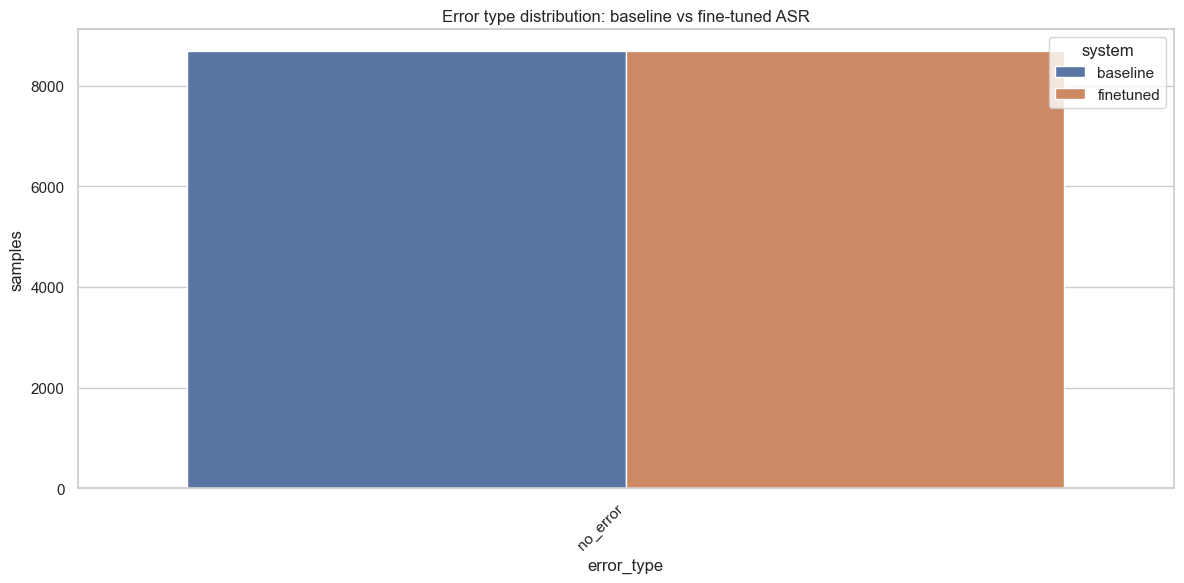

In [62]:
plot_df = error_type_distribution_df.melt(
    id_vars="error_type",
    value_vars=["baseline", "finetuned"],
    var_name="system",
    value_name="samples",
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="error_type", y="samples", hue="system")
plt.xticks(rotation=45, ha="right")
plt.title("Error type distribution: baseline vs fine-tuned ASR")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "error_type_distribution.png", dpi=150)
plt.show()


## Cell 16 — Plot error impact matrix


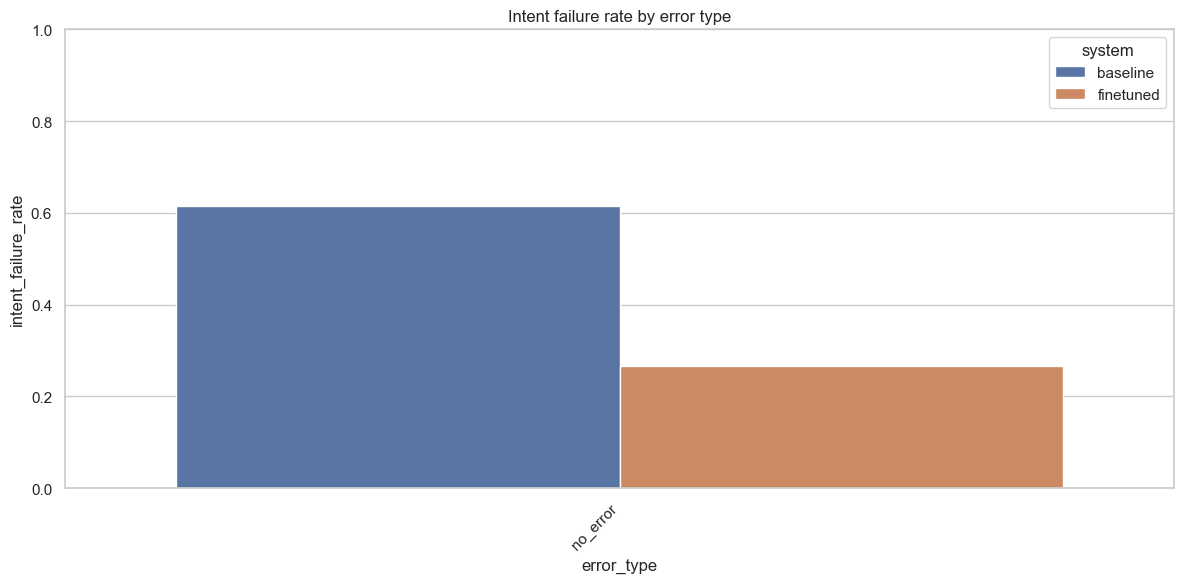

In [63]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=error_impact_matrix_df,
    x="error_type",
    y="intent_failure_rate",
    hue="system",
)
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1.0)
plt.title("Intent failure rate by error type")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "error_impact_matrix.png", dpi=150)
plt.show()


## Cell 17 — Plot intent fragility


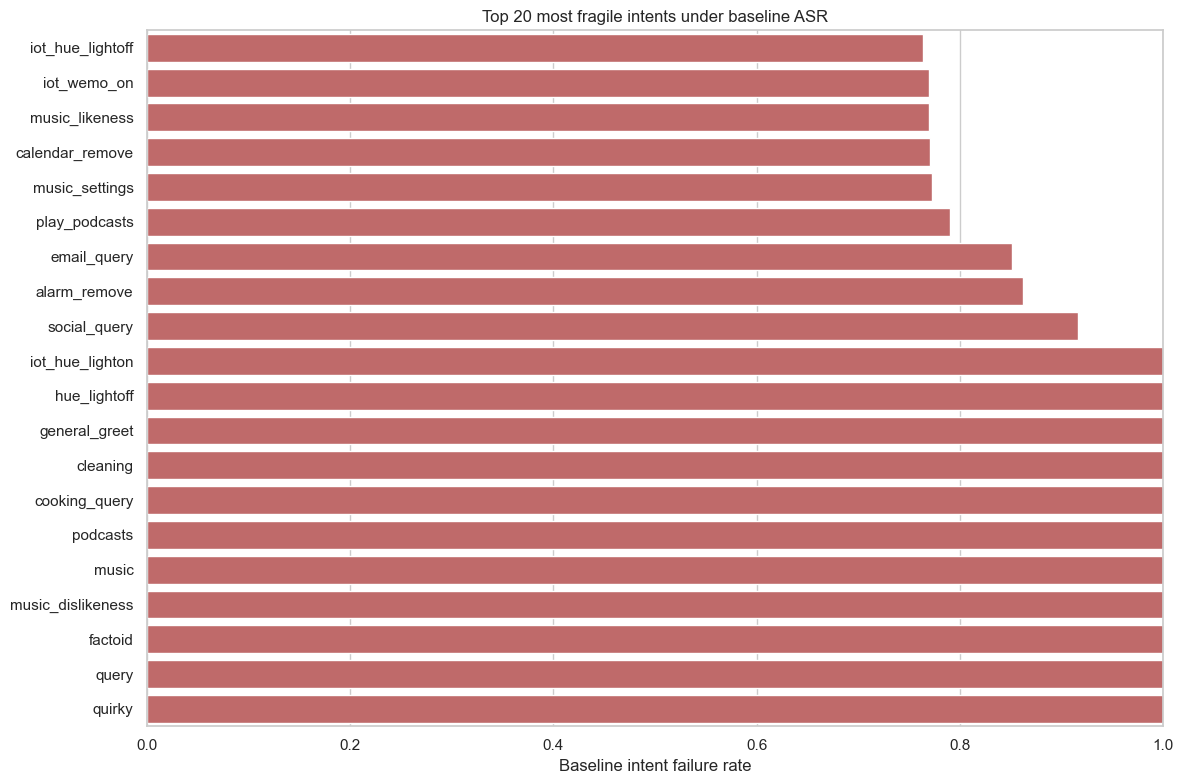

In [64]:
plt.figure(figsize=(12, 8))
plot_fragility_df = intent_fragility_df.head(20).sort_values("baseline_failure_rate", ascending=True)
sns.barplot(data=plot_fragility_df, y="intent", x="baseline_failure_rate", color="indianred")
plt.xlim(0, 1.0)
plt.title("Top 20 most fragile intents under baseline ASR")
plt.xlabel("Baseline intent failure rate")
plt.ylabel("")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "intent_fragility.png", dpi=150)
plt.show()


## Cell 18 — Plot recovery summary


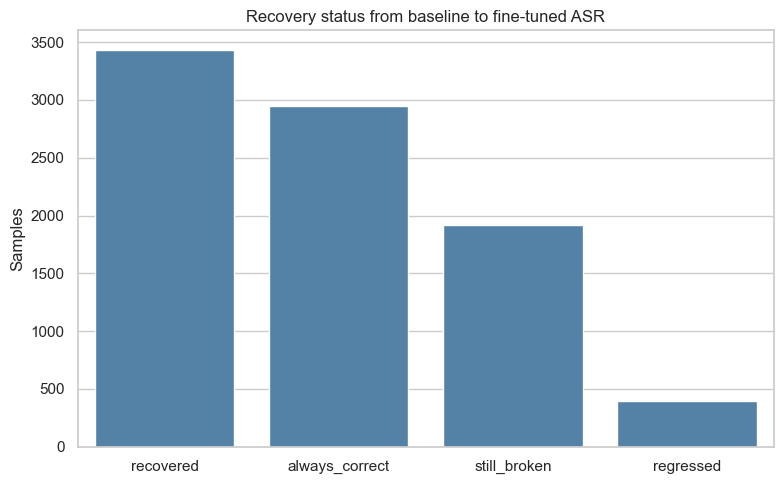

In [65]:
plt.figure(figsize=(8, 5))
sns.barplot(data=recovery_summary_df, x="recovery_status", y="samples", color="steelblue")
plt.title("Recovery status from baseline to fine-tuned ASR")
plt.xlabel("")
plt.ylabel("Samples")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "recovery_summary.png", dpi=150)
plt.show()


In [66]:
row = taxonomy_df.iloc[0]
print(repr(row["ground_truth"]))
print(repr(row["baseline_transcript"]))

gt_check = tokenize_text(row["ground_truth"])
hyp_check = tokenize_text(row["baseline_transcript"])
print("gt_tokens :", gt_check)
print("hyp_tokens:", hyp_check)
print("equal?", gt_check == hyp_check)

info = analyze_transcript_error(row["ground_truth"], row["baseline_transcript"])
print(info)

'siri what is one american dollar in japanese yen'
'SERY WHAT IS ONE AMERICAN DULL IN JAPANESIAN'
gt_tokens : []
hyp_tokens: []
equal? True
{'primary_error_type': 'no_error', 'edit_pattern': 'equal', 'n_substitutions': 0, 'n_insertions': 0, 'n_deletions': 0, 'n_total_edits': 0, 'lexical_overlap': 1.0, 'contains_number_error': False, 'contains_proper_noun_error': False, 'contains_entity_error': False, 'contains_homophone_like_error': False, 'alignment_summary': 'exact_match'}


In [67]:
print(repr(TOKEN_RE.pattern))
print(TOKEN_RE.findall("hello world"))

'\x08\\w+\x08'
[]


## Cell 19 — Save outputs


In [68]:
taxonomy_df.to_csv(ERROR_TAXONOMY_DATASET_PATH, index=False)
error_type_distribution_df.to_csv(REPORTS_DIR / "error_type_distribution.csv", index=False)
error_impact_matrix_df.to_csv(REPORTS_DIR / "error_impact_matrix.csv", index=False)
intent_fragility_df.to_csv(REPORTS_DIR / "intent_fragility.csv", index=False)
recovery_summary_df.to_csv(REPORTS_DIR / "recovery_summary.csv", index=False)
failure_gallery_df.to_csv(REPORTS_DIR / "failure_gallery.csv", index=False)

print("Saved notebook 09 outputs to reports/")


Saved notebook 09 outputs to reports/


## Cell 20 — Final summary


In [69]:
print("=" * 72)
print("ERROR TAXONOMY SUMMARY")
print("=" * 72)
print(f"Rows analyzed: {len(taxonomy_df)}")
print()
print("Most common baseline error types:")
print(error_type_distribution_df.sort_values("baseline", ascending=False)[["error_type", "baseline"]].head(10).to_string(index=False))
print()
print("Highest-impact baseline error types:")
print(
    error_impact_matrix_df[error_impact_matrix_df["system"] == "baseline"]
    .sort_values("intent_failure_rate", ascending=False)[["error_type", "samples", "intent_failure_rate"]]
    .head(10)
    .to_string(index=False)
)
print()
print("Recovery summary:")
print(recovery_summary_df.to_string(index=False))
print()
print(f"Reports saved to: {REPORTS_DIR}")


ERROR TAXONOMY SUMMARY
Rows analyzed: 8688

Most common baseline error types:
error_type  baseline
  no_error      8688

Highest-impact baseline error types:
error_type  samples  intent_failure_rate
  no_error     8688             0.615101

Recovery summary:
recovery_status  samples     rate
      recovered     3430 0.394797
 always_correct     2950 0.339549
   still_broken     1914 0.220304
      regressed      394 0.045350

Reports saved to: c:\Users\ACER\OneDrive\Desktop\VoxIntel\reports
